# Bangladesh Macroeconomic Analysis (2000–2024)

**Author:** Sabahun N Salam · **Data:** World Bank Open Data API (World Development Indicators)

For this report, I analysed Bangladesh with a macroeconomic lens, evaluating its growth. Bangladesh has seen a genuine amount of poverty reduction and poverty resilience, built on remittances and garment exports. However, the country is seeing a declining FDI, currency depreciation, rising external debt-service burden, as well as a stalling female labor force participation. From sections 1-8, I establish Bangladesh's empirical record, while sections 9-12 delve into a financial analysis of Bangladesh. The financial analysis includes debt sustainability, a remittance stress test, a counterfactual using Vietnams FDI, and an exchnage-rate pass-through with the demand-side growth decomposition. 

*Peer set throughout:* Bangladesh, Vietnam, Pakistan, Cambodia.


In [1]:
%matplotlib inline
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

_WB_CACHE = {}

def get_wb_data(indicator, country="BD", start=2000, end=2024, tries=6):
    """Fetch a World Bank indicator as a tidy (Year, Value) DataFrame.
    Retries slow/failed API calls; caches results; returns empty frame if unavailable."""
    key = (indicator, country, start, end)
    if key in _WB_CACHE:
        return _WB_CACHE[key].copy()
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}"
    params = {"format": "json", "per_page": 400, "date": f"{start}:{end}"}
    last_err = None
    for attempt in range(tries):
        try:
            resp = requests.get(url, params=params, timeout=90)
            resp.raise_for_status()
            payload = resp.json()
            data = payload[1] if len(payload) > 1 else None
            if not data:
                last_err = "empty response"; time.sleep(2 * (attempt + 1)); continue
            df = pd.DataFrame(data)[["date", "value"]].dropna()
            df.columns = ["Year", "Value"]
            df["Year"] = df["Year"].astype(int)
            df = df[(df["Year"] >= start) & (df["Year"] <= end)]
            df = df.sort_values("Year").reset_index(drop=True)
            _WB_CACHE[key] = df
            return df.copy()
        except Exception as e:
            last_err = repr(e); time.sleep(2 * (attempt + 1))
    print(f"  WARNING: no data returned for {indicator} ({country}): {last_err}")
    return pd.DataFrame(columns=["Year", "Value"])

def get_wb_data_safe(indicator, country="BD"):
    df = get_wb_data(indicator, country=country)
    return df if not df.empty else None

## Section 1 — Bangladesh Macroeconomic Overview (2000–2024)

In [2]:
# Core indicators for Bangladesh
indicators = {
    "NY.GDP.MKTP.KD.ZG": "GDP Growth (%)",
    "FP.CPI.TOTL.ZG":    "Inflation (%)",
    "SI.POV.DDAY":       "Poverty Rate (%)",
    "BX.KLT.DINV.WD.GD.ZS": "FDI (% of GDP)",
}

bd_core = {}
for code_, name in indicators.items():
    bd_core[name] = get_wb_data(code_, country="BD")
    print(f"Fetched: {name}  ({len(bd_core[name])} obs)")
print("\nCore data loaded.")


Fetched: GDP Growth (%)  (25 obs)


Fetched: Inflation (%)  (25 obs)


Fetched: Poverty Rate (%)  (5 obs)


Fetched: FDI (% of GDP)  (25 obs)

Core data loaded.


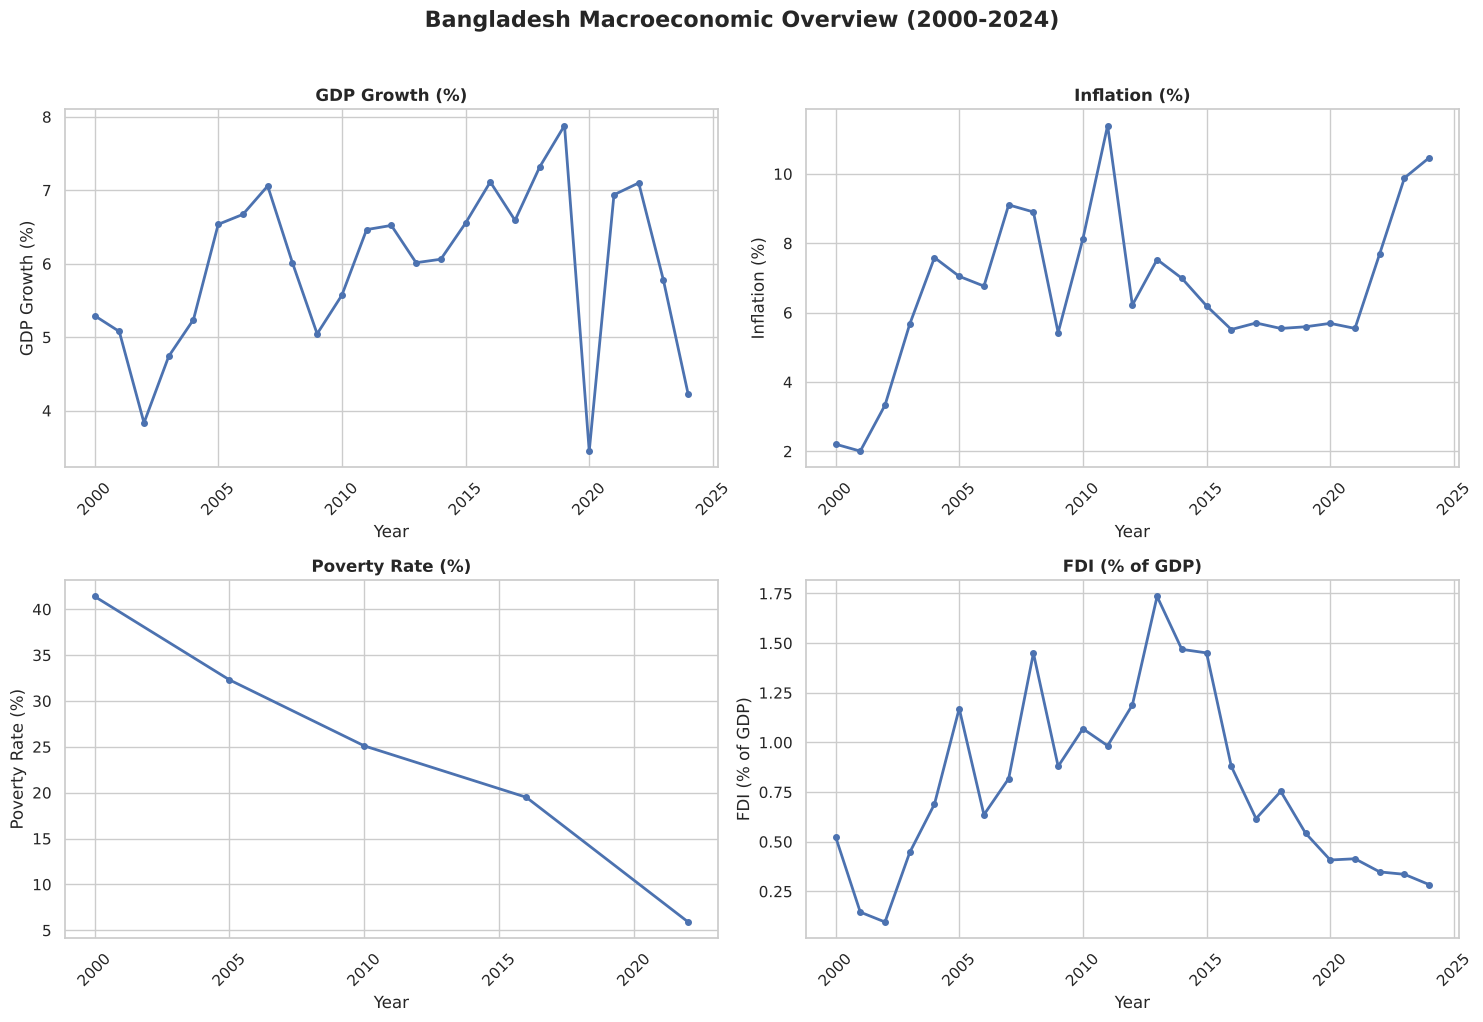

Saved Bangladesh_macro.png


In [3]:
# 2x2 overview grid  (FIX: iterate over bd_core, not an undefined `df`)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Bangladesh Macroeconomic Overview (2000-2024)",
             fontsize=16, fontweight="bold", y=1.02)

for ax, (name, df) in zip(axes.flatten(), bd_core.items()):
    ax.plot(df["Year"], df["Value"], marker="o", linewidth=2, markersize=4)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel(name)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("Bangladesh_macro.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Bangladesh_macro.png")


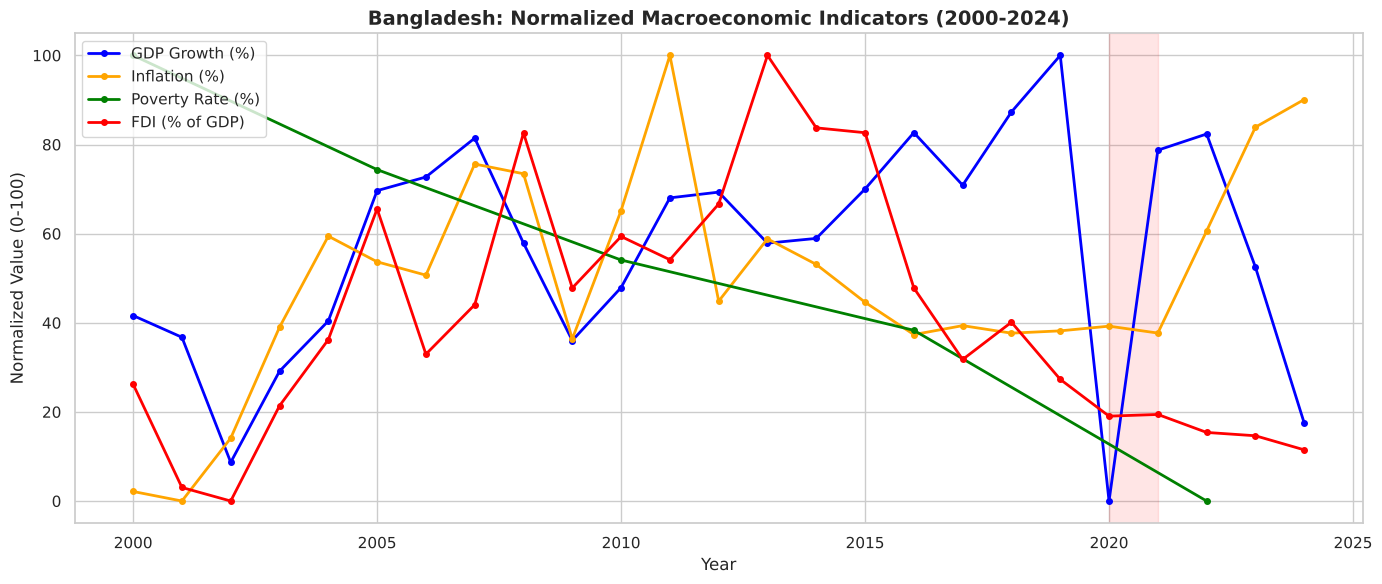

Saved Bangladesh_macro_normalized.png


In [4]:
# Normalized 0-100 comparison of the four indicators on one axis
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["blue", "orange", "green", "red"]

for (name, df), color in zip(bd_core.items(), colors):
    norm = (df["Value"] - df["Value"].min()) / (df["Value"].max() - df["Value"].min()) * 100
    ax.plot(df["Year"], norm, marker="o", linewidth=2, markersize=4, label=name, color=color)

ax.set_title("Bangladesh: Normalized Macroeconomic Indicators (2000-2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Normalized Value (0-100)")
ax.axvspan(2020, 2021, alpha=0.1, color="red")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("Bangladesh_macro_normalized.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Bangladesh_macro_normalized.png")


## Section 2 — Peer Comparison (GDP Growth & Poverty)

In [5]:
countries = {"BD": "Bangladesh", "VN": "Vietnam", "PK": "Pakistan", "KH": "Cambodia"}

peer_gdp = {}
for c, name in countries.items():
    r = get_wb_data_safe("NY.GDP.MKTP.KD.ZG", country=c)
    if r is not None: peer_gdp[name] = r; print(f"GDP growth: {name}")

peer_poverty = {}
for c, name in countries.items():
    r = get_wb_data_safe("SI.POV.DDAY", country=c)
    if r is not None: peer_poverty[name] = r; print(f"Poverty: {name}")
print("\nPeer data loaded.")


GDP growth: Bangladesh


GDP growth: Vietnam


GDP growth: Pakistan


GDP growth: Cambodia
Poverty: Bangladesh


Poverty: Vietnam


Poverty: Pakistan



Peer data loaded.


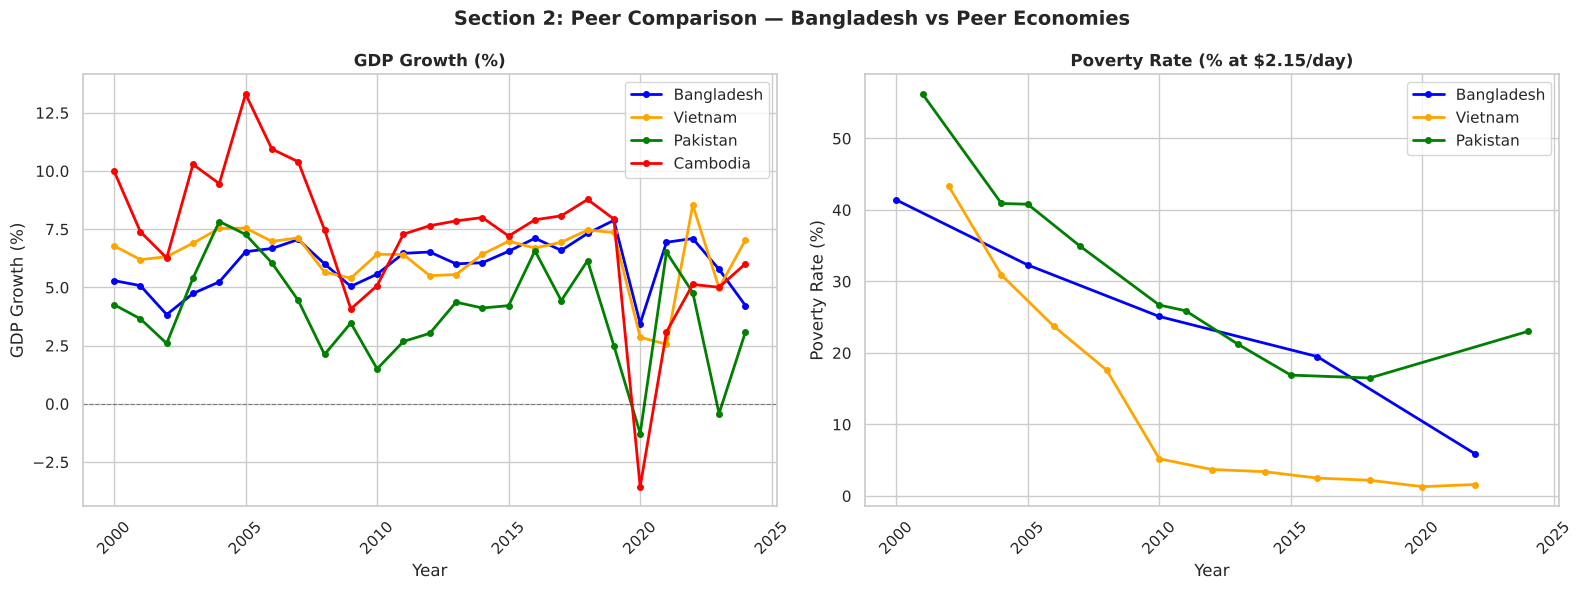

Saved Peer_comparison.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Section 2: Peer Comparison — Bangladesh vs Peer Economies",
             fontsize=14, fontweight="bold")
colors = ["blue", "orange", "green", "red"]

for (name, df), color in zip(peer_gdp.items(), colors):
    ax1.plot(df["Year"], df["Value"], marker="o", linewidth=2, markersize=4, label=name, color=color)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax1.set_title("GDP Growth (%)", fontweight="bold"); ax1.set_xlabel("Year")
ax1.set_ylabel("GDP Growth (%)"); ax1.legend(); ax1.tick_params(axis="x", rotation=45)

for (name, df), color in zip(peer_poverty.items(), colors):
    ax2.plot(df["Year"], df["Value"], marker="o", linewidth=2, markersize=4, label=name, color=color)
ax2.set_title("Poverty Rate (% at $2.15/day)", fontweight="bold"); ax2.set_xlabel("Year")
ax2.set_ylabel("Poverty Rate (%)"); ax2.legend(); ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("Peer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Peer_comparison.png")


## Sections 3–6 — Supplementary Indicator Pull

In [7]:
new_indicators = {
    "BX.TRF.PWKR.DT.GD.ZS": "Remittances (% of GDP)",
    "SL.TLF.CACT.FE.ZS":    "Female Labor Force Participation (%)",
    "HD.HCI.OVRL":          "Human Capital Index",
    "SE.ADT.LITR.ZS":       "Adult Literacy Rate (%)",
    "SP.DYN.LE00.IN":       "Life Expectancy (years)",
    "DT.DOD.DECT.GN.ZS":    "External Debt (% of GNI)",
    "PA.NUS.FCRF":          "Exchange Rate (BDT per USD)",
}
bd_extra = {}
for c, name in new_indicators.items():
    r = get_wb_data_safe(c, country="BD")
    if r is not None: bd_extra[name] = r; print(f"Fetched {name}")

peer_lfp, peer_hci = {}, {}
for c, name in countries.items():
    r1 = get_wb_data_safe("SL.TLF.CACT.FE.ZS", country=c)
    if r1 is not None: peer_lfp[name] = r1
    r2 = get_wb_data_safe("HD.HCI.OVRL", country=c)
    if r2 is not None: peer_hci[name] = r2
print("\nSupplementary + peer LFP/HCI data loaded.")


Fetched Remittances (% of GDP)


Fetched Female Labor Force Participation (%)


Fetched Human Capital Index


Fetched Adult Literacy Rate (%)


Fetched Life Expectancy (years)


Fetched External Debt (% of GNI)


Fetched Exchange Rate (BDT per USD)



Supplementary + peer LFP/HCI data loaded.


## Section 3 — Remittances vs FDI

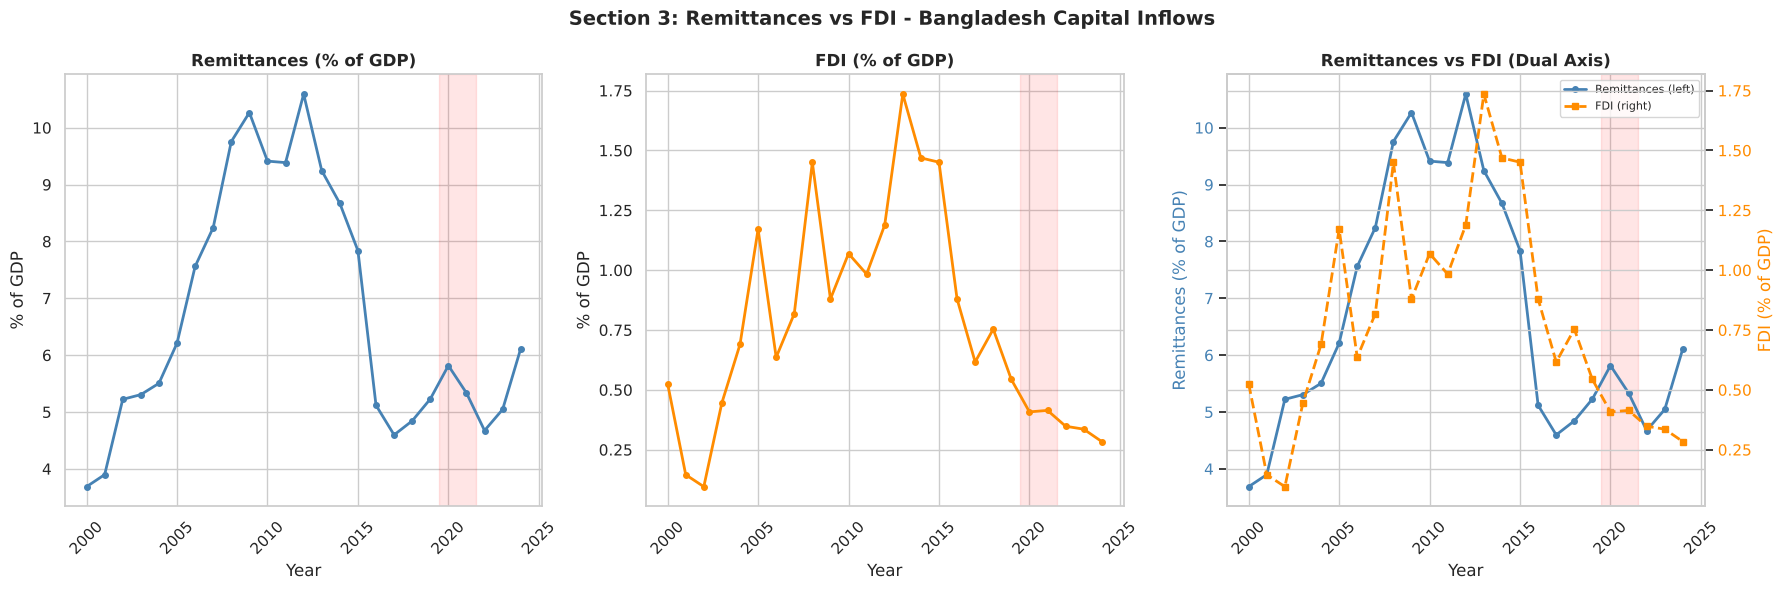

Saved Section3_Remittances_FDI.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section 3: Remittances vs FDI - Bangladesh Capital Inflows",
             fontsize=14, fontweight="bold")
remit = bd_extra.get("Remittances (% of GDP)")
fdi   = bd_core.get("FDI (% of GDP)")

ax1 = axes[0]
ax1.plot(remit["Year"], remit["Value"], marker="o", color="steelblue", linewidth=2, markersize=4)
ax1.axvspan(2019.5, 2021.5, alpha=0.1, color="red")
ax1.set_title("Remittances (% of GDP)", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("% of GDP"); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[1]
ax2.plot(fdi["Year"], fdi["Value"], marker="o", color="darkorange", linewidth=2, markersize=4)
ax2.axvspan(2019.5, 2021.5, alpha=0.1, color="red")
ax2.set_title("FDI (% of GDP)", fontweight="bold")
ax2.set_xlabel("Year"); ax2.set_ylabel("% of GDP"); ax2.tick_params(axis="x", rotation=45)

ax3 = axes[2]; ax3r = ax3.twinx()
ax3.plot(remit["Year"], remit["Value"], marker="o", color="steelblue", linewidth=2, markersize=4, label="Remittances (left)")
ax3.set_ylabel("Remittances (% of GDP)", color="steelblue"); ax3.tick_params(axis="y", labelcolor="steelblue")
ax3r.plot(fdi["Year"], fdi["Value"], marker="s", color="darkorange", linewidth=2, markersize=4, linestyle="--", label="FDI (right)")
ax3r.set_ylabel("FDI (% of GDP)", color="darkorange"); ax3r.tick_params(axis="y", labelcolor="darkorange")
ax3.axvspan(2019.5, 2021.5, alpha=0.1, color="red")
ax3.set_title("Remittances vs FDI (Dual Axis)", fontweight="bold"); ax3.set_xlabel("Year"); ax3.tick_params(axis="x", rotation=45)
l1, lab1 = ax3.get_legend_handles_labels(); l2, lab2 = ax3r.get_legend_handles_labels()
ax3.legend(l1 + l2, lab1 + lab2, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("Section3_Remittances_FDI.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Section3_Remittances_FDI.png")


## Section 4 — Female Labor Force Participation + Human Capital Index

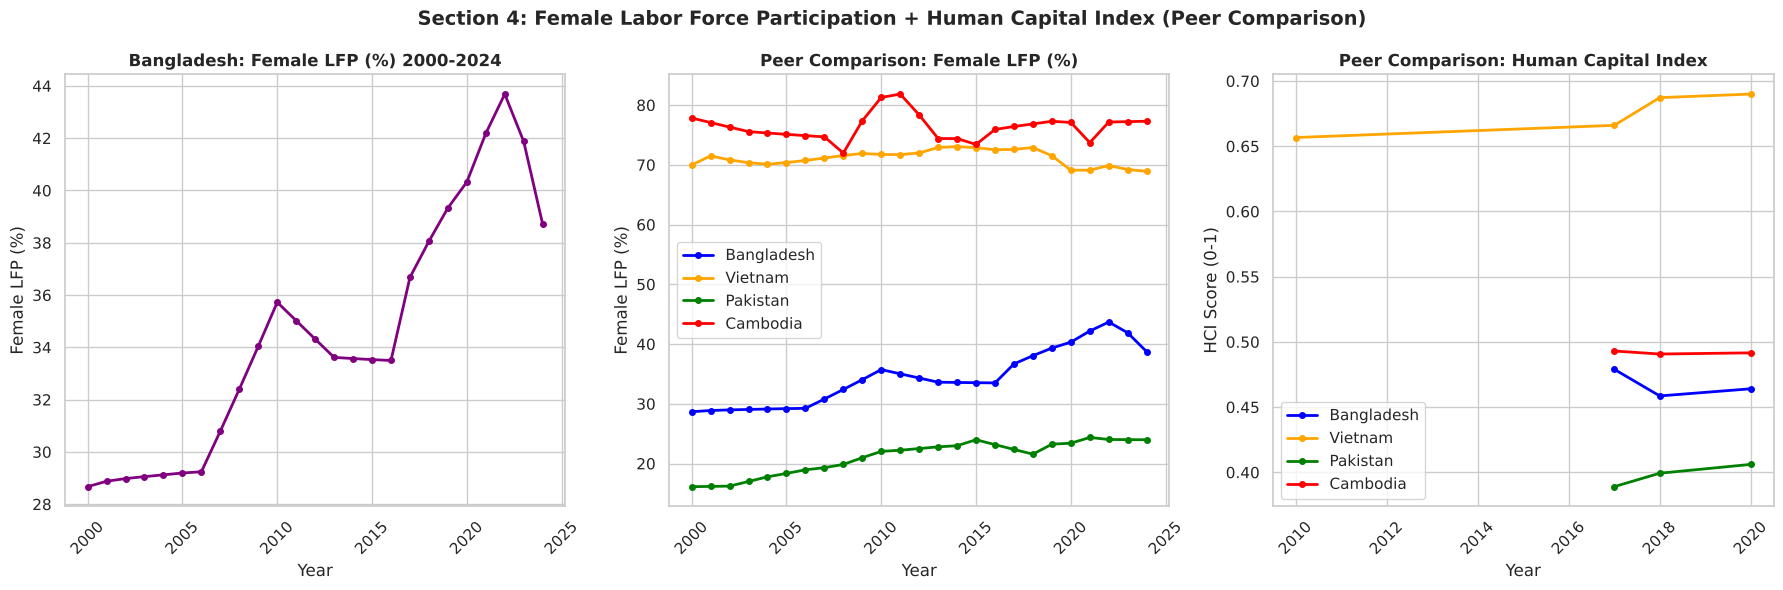

Saved Section4_Gender_HCI.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section 4: Female Labor Force Participation + Human Capital Index (Peer Comparison)",
             fontsize=14, fontweight="bold")
colors = ["blue", "orange", "green", "red"]

ax1 = axes[0]
bd_lfp = bd_extra.get("Female Labor Force Participation (%)")
ax1.plot(bd_lfp["Year"], bd_lfp["Value"], marker="o", color="purple", linewidth=2, markersize=4)
ax1.set_title("Bangladesh: Female LFP (%) 2000-2024", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("Female LFP (%)"); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[1]   # FIX: peer_lfp (was undefined peer_gender)
for (name, df), color in zip(peer_lfp.items(), colors):
    ax2.plot(df["Year"], df["Value"], marker="o", linewidth=2, markersize=4, label=name, color=color)
ax2.set_title("Peer Comparison: Female LFP (%)", fontweight="bold")
ax2.set_xlabel("Year"); ax2.set_ylabel("Female LFP (%)"); ax2.legend(); ax2.tick_params(axis="x", rotation=45)

ax3 = axes[2]
if peer_hci:
    for (name, df), color in zip(peer_hci.items(), colors):
        ax3.plot(df["Year"], df["Value"], marker="o", linewidth=2, markersize=4, label=name, color=color)
    ax3.set_title("Peer Comparison: Human Capital Index", fontweight="bold")
    ax3.set_xlabel("Year"); ax3.set_ylabel("HCI Score (0-1)"); ax3.legend(); ax3.tick_params(axis="x", rotation=45)
else:
    ax3.text(0.5, 0.5, "No HCI data available", ha="center", va="center", transform=ax3.transAxes, color="gray")
    ax3.set_title("Peer Comparison: Human Capital Index", fontweight="bold")

plt.tight_layout()
plt.savefig("Section4_Gender_HCI.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Section4_Gender_HCI.png")


## Section 5 — Exchange Rate & External Debt

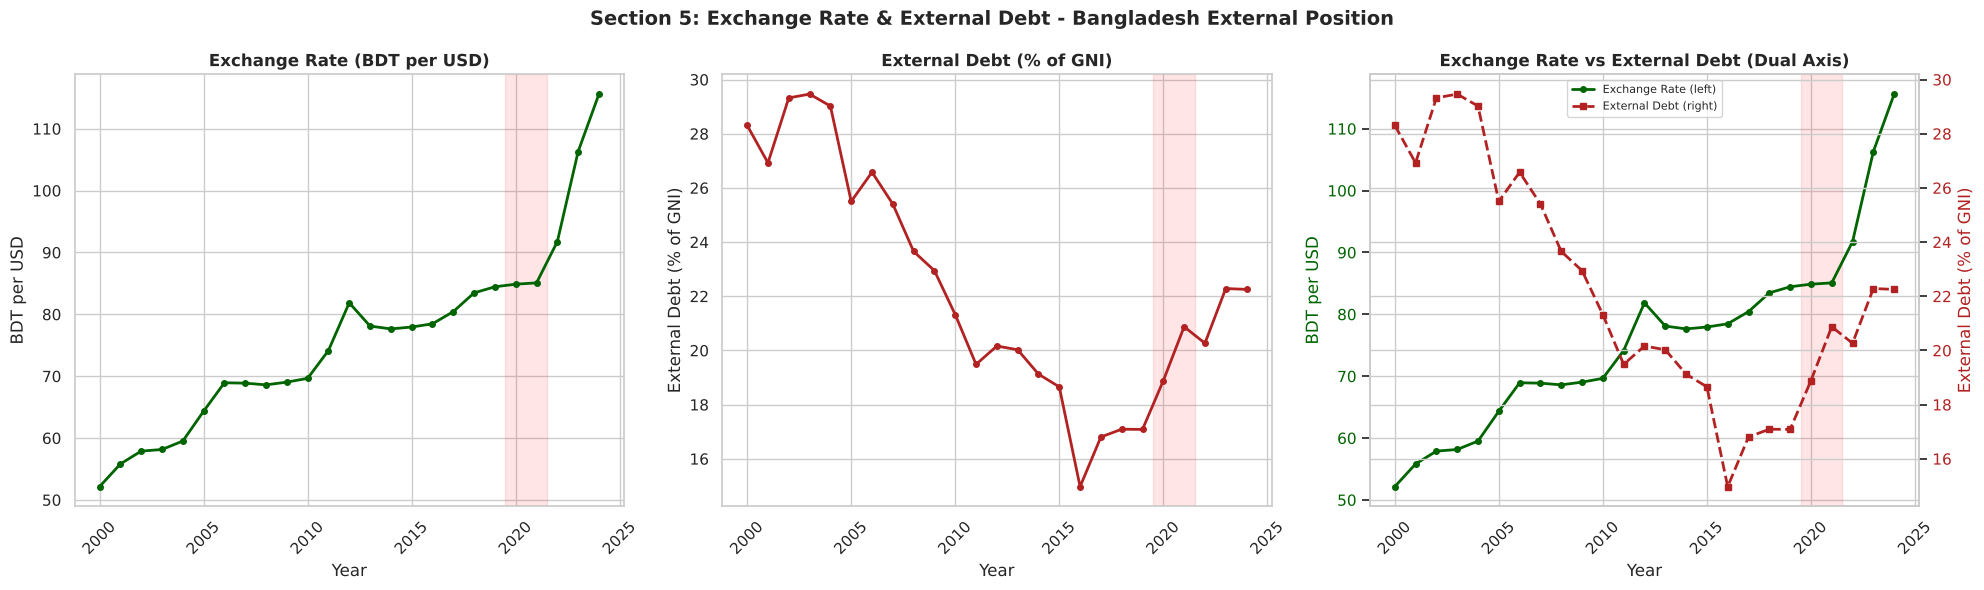

Saved Section5_ExchangeRate_Debt.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section 5: Exchange Rate & External Debt - Bangladesh External Position",
             fontsize=14, fontweight="bold")
exchange = bd_extra.get("Exchange Rate (BDT per USD)")
debt     = bd_extra.get("External Debt (% of GNI)")

ax1 = axes[0]
ax1.plot(exchange["Year"], exchange["Value"], marker="o", color="darkgreen", linewidth=2, markersize=4)
ax1.axvspan(2019.5, 2021.5, alpha=0.1, color="red")
ax1.set_title("Exchange Rate (BDT per USD)", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("BDT per USD"); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[1]
ax2.plot(debt["Year"], debt["Value"], marker="o", color="firebrick", linewidth=2, markersize=4)
ax2.axvspan(2019.5, 2021.5, alpha=0.1, color="red")
ax2.set_title("External Debt (% of GNI)", fontweight="bold")
ax2.set_xlabel("Year"); ax2.set_ylabel("External Debt (% of GNI)"); ax2.tick_params(axis="x", rotation=45)

ax3 = axes[2]; ax3r = ax3.twinx()
ax3.plot(exchange["Year"], exchange["Value"], marker="o", color="darkgreen", linewidth=2, markersize=4, label="Exchange Rate (left)")
ax3.set_ylabel("BDT per USD", color="darkgreen"); ax3.tick_params(axis="y", labelcolor="darkgreen")
ax3r.plot(debt["Year"], debt["Value"], marker="s", color="firebrick", linewidth=2, markersize=4, linestyle="--", label="External Debt (right)")
ax3r.set_ylabel("External Debt (% of GNI)", color="firebrick"); ax3r.tick_params(axis="y", labelcolor="firebrick")
ax3.axvspan(2019.5, 2021.5, alpha=0.1, color="red")
ax3.set_title("Exchange Rate vs External Debt (Dual Axis)", fontweight="bold"); ax3.set_xlabel("Year"); ax3.tick_params(axis="x", rotation=45)
l1, lab1 = ax3.get_legend_handles_labels(); l2, lab2 = ax3r.get_legend_handles_labels()
ax3.legend(l1 + l2, lab1 + lab2, loc="upper center", fontsize=8)

plt.tight_layout()
plt.savefig("Section5_ExchangeRate_Debt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Section5_ExchangeRate_Debt.png")


## Section 6 — Education & Female LFP Linkage (5-Year Lag)

Tests whether rising adult literacy in year *T* predicts higher female labor force
participation five years later (*T+5*). `lagged_pairs` is constructed explicitly below
(this was the source of the original notebook error).

In [11]:
literacy = bd_extra.get("Adult Literacy Rate (%)")
lfp      = bd_extra.get("Female Labor Force Participation (%)")

# FIX: build the lagged pairs that the plot depends on.
lit_map = dict(zip(literacy["Year"], literacy["Value"]))
lfp_map = dict(zip(lfp["Year"], lfp["Value"]))
lagged_pairs = []
for yr, lit_val in lit_map.items():
    if (yr + 5) in lfp_map:
        lagged_pairs.append({"Literacy_Year": yr, "Literacy": lit_val,
                             "LFP_Year": yr + 5, "LFP": lfp_map[yr + 5]})
lag_df = pd.DataFrame(lagged_pairs).sort_values("Literacy_Year").reset_index(drop=True)
print(f"Constructed {len(lag_df)} lagged (T, T+5) pairs")
print(lag_df.to_string(index=False))


Constructed 10 lagged (T, T+5) pairs
 Literacy_Year  Literacy  LFP_Year    LFP
          2001 47.490002      2006 29.241
          2011 58.770000      2016 33.497
          2012 57.860001      2017 36.676
          2013 61.020000      2018 38.056
          2014 61.090000      2019 39.330
          2015 65.139999      2020 40.323
          2016 72.760002      2021 42.181
          2017 72.889999      2022 43.687
          2018 73.910004      2023 41.874
          2019 74.680000      2024 38.708


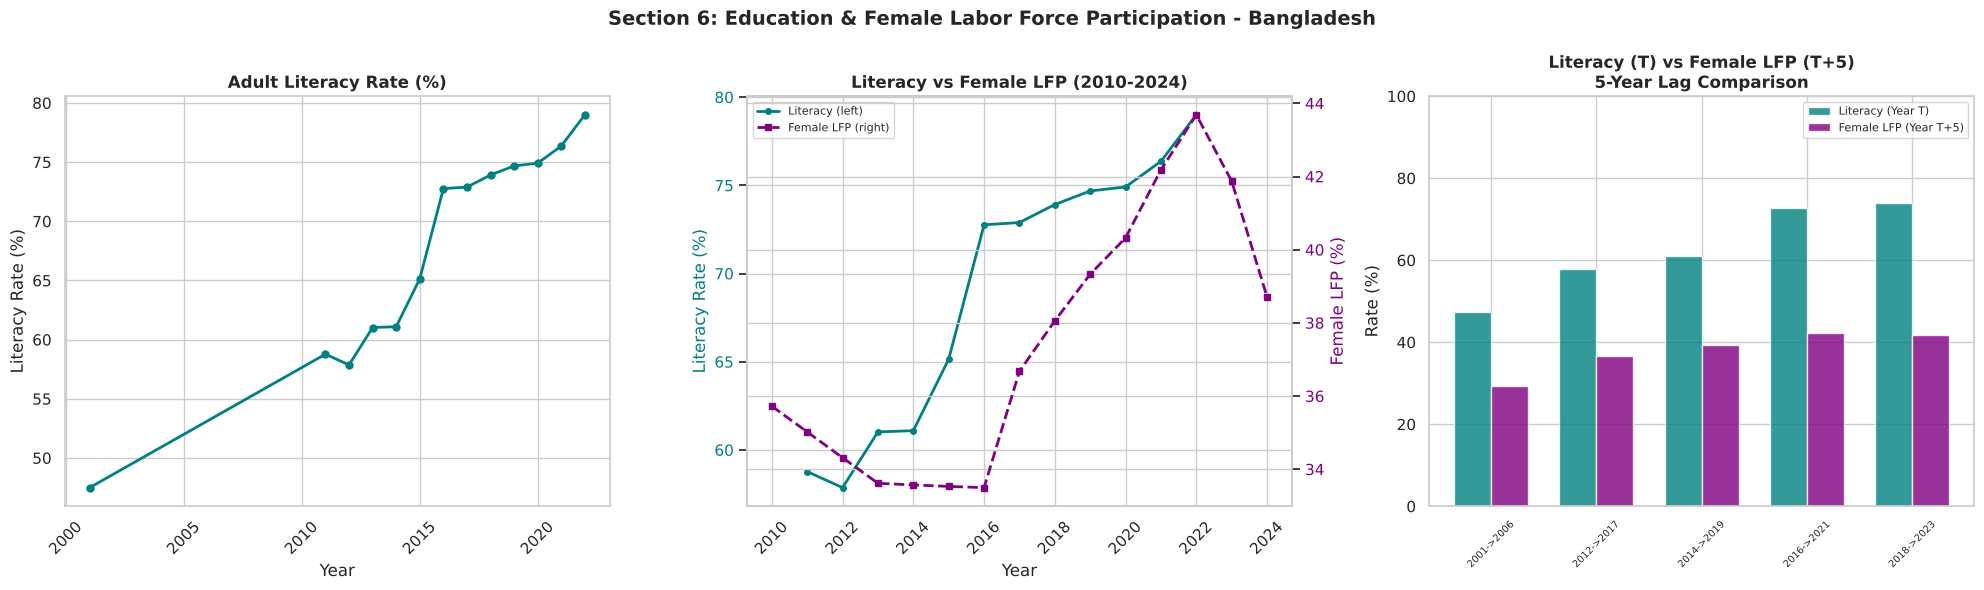

Saved Section6_Education_LFP.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section 6: Education & Female Labor Force Participation - Bangladesh",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
ax1.plot(literacy["Year"], literacy["Value"], marker="o", color="teal", linewidth=2, markersize=5)
ax1.set_title("Adult Literacy Rate (%)", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("Literacy Rate (%)"); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[1]; ax2r = ax2.twinx()
lit_o = literacy[literacy["Year"] >= 2010]; lfp_o = lfp[lfp["Year"] >= 2010]
ax2.plot(lit_o["Year"], lit_o["Value"], marker="o", color="teal", linewidth=2, markersize=4, label="Literacy (left)")
ax2.set_ylabel("Literacy Rate (%)", color="teal"); ax2.tick_params(axis="y", labelcolor="teal")
ax2r.plot(lfp_o["Year"], lfp_o["Value"], marker="s", color="purple", linewidth=2, markersize=4, linestyle="--", label="Female LFP (right)")
ax2r.set_ylabel("Female LFP (%)", color="purple"); ax2r.tick_params(axis="y", labelcolor="purple")
ax2.set_title("Literacy vs Female LFP (2010-2024)", fontweight="bold"); ax2.set_xlabel("Year"); ax2.tick_params(axis="x", rotation=45)
l1, lab1 = ax2.get_legend_handles_labels(); l2, lab2 = ax2r.get_legend_handles_labels()
ax2.legend(l1 + l2, lab1 + lab2, loc="upper left", fontsize=8)

ax3 = axes[2]
plot_df = lag_df.iloc[::2].reset_index(drop=True) if len(lag_df) > 8 else lag_df
x = np.arange(len(plot_df)); w = 0.35
ax3.bar(x - w/2, plot_df["Literacy"], w, label="Literacy (Year T)", color="teal", alpha=0.8)
ax3.bar(x + w/2, plot_df["LFP"], w, label="Female LFP (Year T+5)", color="purple", alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels([f"{int(r.Literacy_Year)}->{int(r.LFP_Year)}" for r in plot_df.itertuples()], rotation=45, fontsize=7)
ax3.set_title("Literacy (T) vs Female LFP (T+5)\n5-Year Lag Comparison", fontweight="bold")
ax3.set_ylabel("Rate (%)"); ax3.set_ylim(0, 100); ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig("Section6_Education_LFP.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Section6_Education_LFP.png")


## Section 7 — Political Cycle Overlay

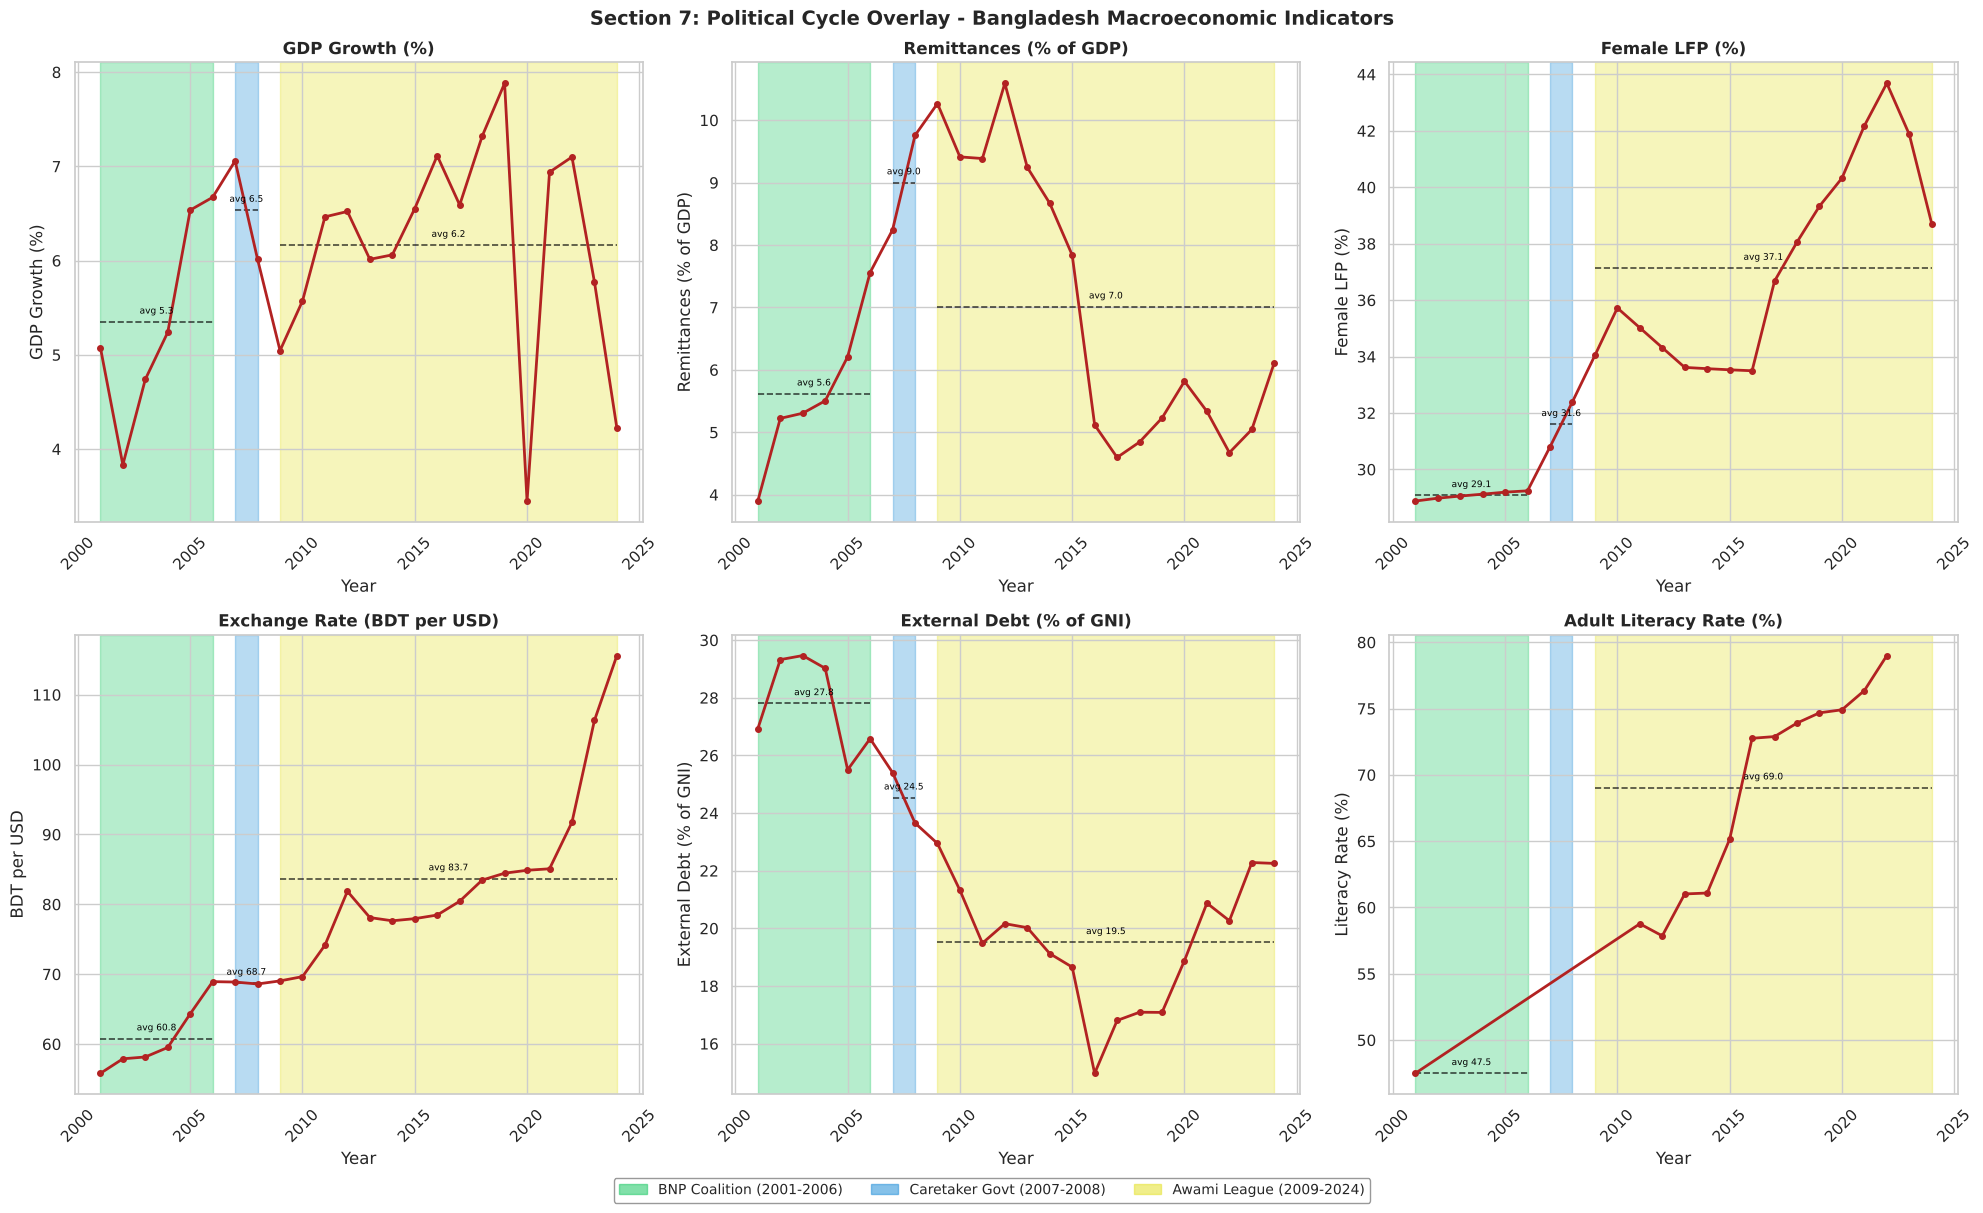

Saved Section7_Political_Overlay.png


In [13]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Section 7: Political Cycle Overlay - Bangladesh Macroeconomic Indicators",
             fontsize=14, fontweight="bold")

political_periods = [
    (2001, 2006, "#2ecc71", "BNP Coalition"),
    (2007, 2008, "#3498db", "Caretaker Govt"),
    (2009, 2024, "#e7e43c", "Awami League"),
]
def add_overlay(ax):
    for s, e, color, _ in political_periods:
        ax.axvspan(s, e, alpha=0.35, color=color, zorder=0)

series = [
    ("GDP Growth (%)",              bd_core.get("GDP Growth (%)"),                       "GDP Growth (%)"),
    ("Remittances (% of GDP)",      bd_extra.get("Remittances (% of GDP)"),              "Remittances (% of GDP)"),
    ("Female LFP (%)",              bd_extra.get("Female Labor Force Participation (%)"), "Female LFP (%)"),
    ("Exchange Rate (BDT per USD)", bd_extra.get("Exchange Rate (BDT per USD)"),         "BDT per USD"),
    ("External Debt (% of GNI)",    bd_extra.get("External Debt (% of GNI)"),            "External Debt (% of GNI)"),
    ("Adult Literacy Rate (%)",     bd_extra.get("Adult Literacy Rate (%)"),             "Literacy Rate (%)"),
]
for ax, (title, df, ylabel) in zip(axes.flatten(), series):
    dfp = df[df["Year"] >= 2001]
    add_overlay(ax)
    ax.plot(dfp["Year"], dfp["Value"], marker="o", color="firebrick", linewidth=2, markersize=4, zorder=3)
    for s, e, _, _ in political_periods:
        pdat = dfp[(dfp["Year"] >= s) & (dfp["Year"] <= e)]
        if not pdat.empty:
            avg = pdat["Value"].mean()
            ax.hlines(avg, s, e, colors="black", linewidth=1.2, linestyle="--", alpha=0.7, zorder=2)
            ax.annotate(f"avg {avg:.1f}", xy=(s + (e - s)/2, avg), xytext=(0, 6),
                        textcoords="offset points", fontsize=6.5, color="black", ha="center")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Year"); ax.set_ylabel(ylabel); ax.tick_params(axis="x", rotation=45)

handles = [mpatches.Patch(color=c, alpha=0.6, label=f"{lab} ({s}-{e})") for s, e, c, lab in political_periods]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=True, edgecolor="gray")
plt.tight_layout()
plt.savefig("Section7_Political_Overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Section7_Political_Overlay.png")


## Section 8 — COVID Shock Resilience

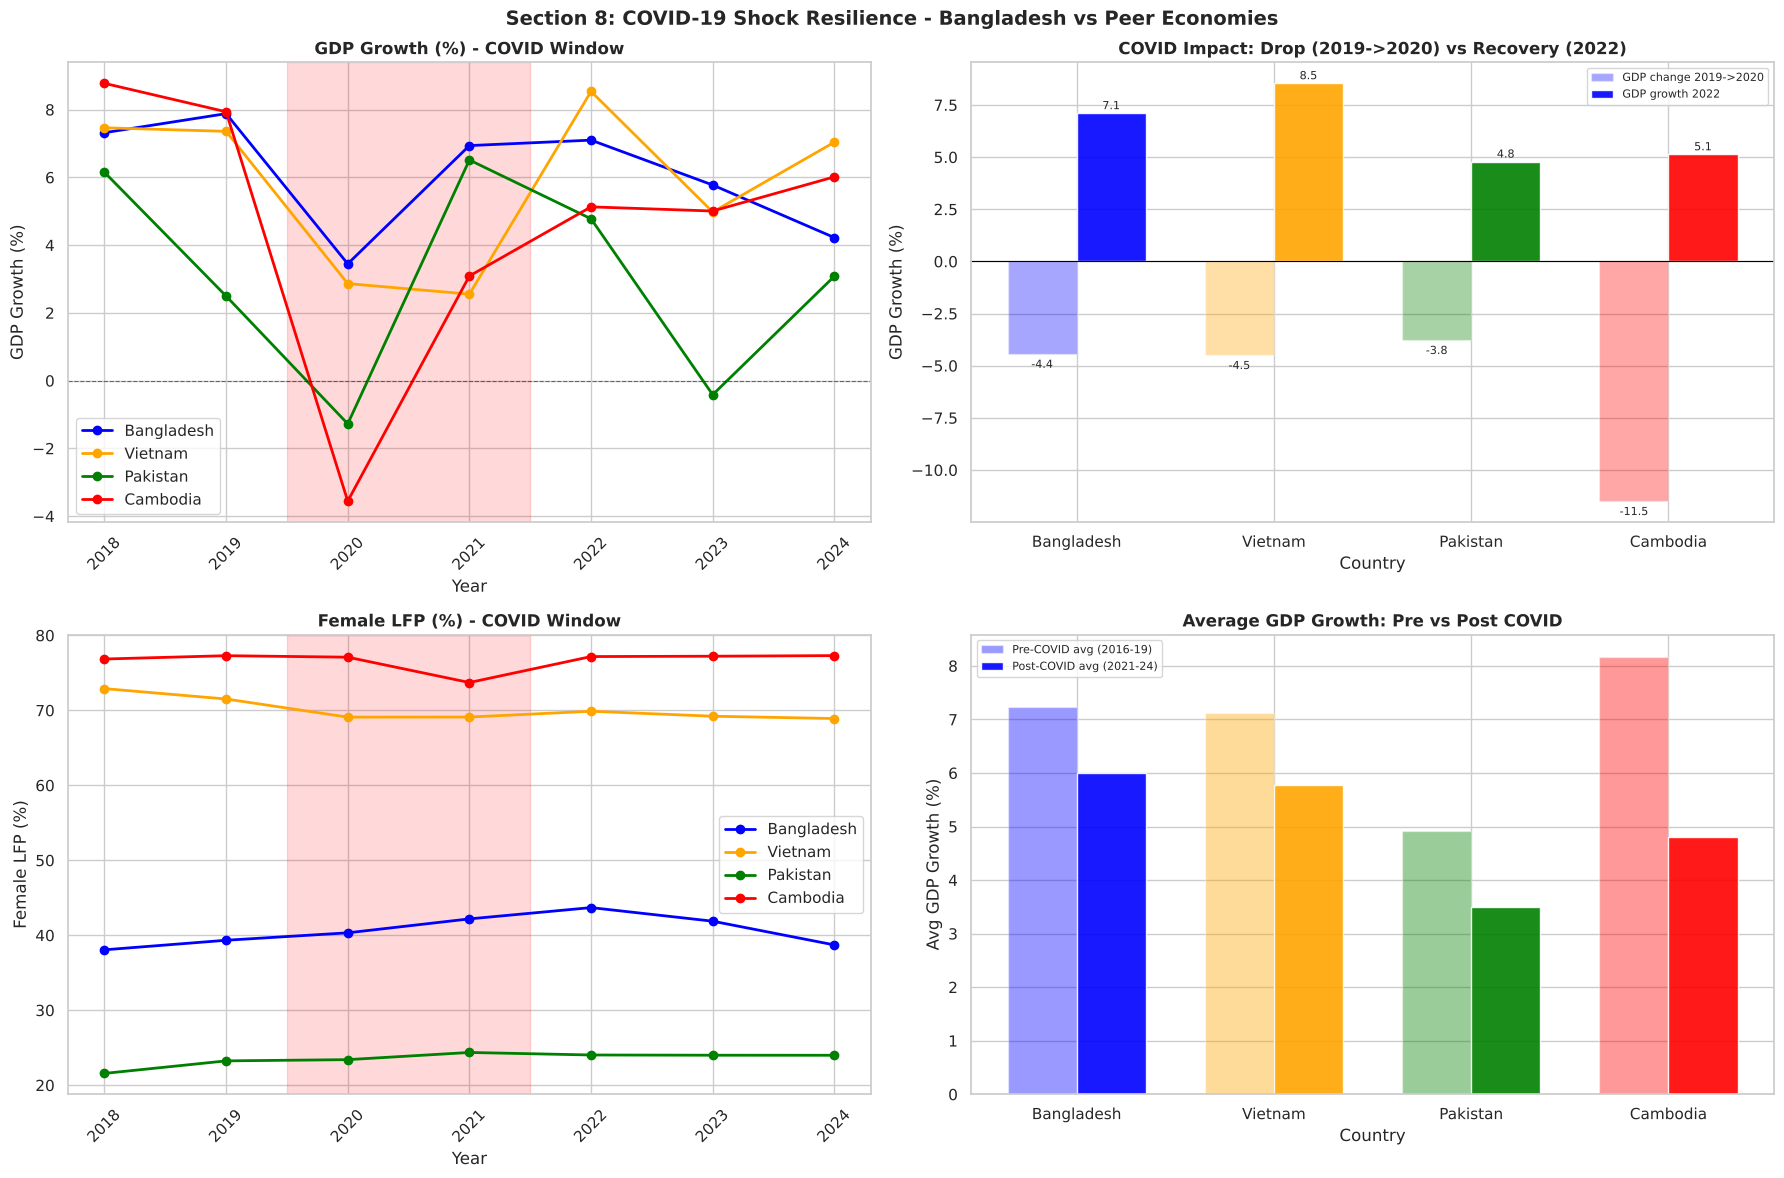

Saved Section8_COVID_Resilience.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Section 8: COVID-19 Shock Resilience - Bangladesh vs Peer Economies",
             fontsize=14, fontweight="bold")
cmap = {"Bangladesh": "blue", "Vietnam": "orange", "Pakistan": "green", "Cambodia": "red"}
win = (2018, 2024)

ax1 = axes[0][0]
for name, df in peer_gdp.items():
    d = df[(df["Year"] >= win[0]) & (df["Year"] <= win[1])]
    ax1.plot(d["Year"], d["Value"], marker="o", linewidth=2, markersize=6, label=name, color=cmap[name])
ax1.axvspan(2019.5, 2021.5, alpha=0.15, color="red"); ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax1.set_title("GDP Growth (%) - COVID Window", fontweight="bold"); ax1.set_xlabel("Year"); ax1.set_ylabel("GDP Growth (%)"); ax1.legend(); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[0][1]
drop_d, rec_d = {}, {}
for name, df in peer_gdp.items():
    pre = df[df["Year"] == 2019]["Value"].values
    dro = df[df["Year"] == 2020]["Value"].values
    rec = df[df["Year"] == 2022]["Value"].values
    if len(pre) and len(dro) and len(rec):
        drop_d[name] = float(dro[0]) - float(pre[0]); rec_d[name] = float(rec[0])
x = np.arange(len(drop_d)); w = 0.35
b1 = ax2.bar(x - w/2, list(drop_d.values()), w, label="GDP change 2019->2020", color=[cmap[n] for n in drop_d], alpha=0.35)
b2 = ax2.bar(x + w/2, list(rec_d.values()), w, label="GDP growth 2022", color=[cmap[n] for n in rec_d], alpha=0.9)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("COVID Impact: Drop (2019->2020) vs Recovery (2022)", fontweight="bold")
ax2.set_xlabel("Country"); ax2.set_ylabel("GDP Growth (%)"); ax2.set_xticks(x); ax2.set_xticklabels(list(drop_d.keys())); ax2.legend(fontsize=8)
for b in list(b1) + list(b2):
    ax2.annotate(f"{b.get_height():.1f}", xy=(b.get_x() + b.get_width()/2, b.get_height()),
                 xytext=(0, 3 if b.get_height() >= 0 else -10), textcoords="offset points", ha="center", fontsize=8)

ax3 = axes[1][0]
for name, df in peer_lfp.items():
    d = df[(df["Year"] >= win[0]) & (df["Year"] <= win[1])]
    ax3.plot(d["Year"], d["Value"], marker="o", linewidth=2, markersize=6, label=name, color=cmap[name])
ax3.axvspan(2019.5, 2021.5, alpha=0.15, color="red")
ax3.set_title("Female LFP (%) - COVID Window", fontweight="bold"); ax3.set_xlabel("Year"); ax3.set_ylabel("Female LFP (%)"); ax3.legend(); ax3.tick_params(axis="x", rotation=45)

ax4 = axes[1][1]
pre_avg = {name: df[(df["Year"] >= 2016) & (df["Year"] <= 2019)]["Value"].mean() for name, df in peer_gdp.items()}
post_avg = {name: df[(df["Year"] >= 2021) & (df["Year"] <= 2024)]["Value"].mean() for name, df in peer_gdp.items()}
x = np.arange(len(pre_avg)); w = 0.35
ax4.bar(x - w/2, list(pre_avg.values()), w, label="Pre-COVID avg (2016-19)", color=[cmap[n] for n in pre_avg], alpha=0.4)
ax4.bar(x + w/2, list(post_avg.values()), w, label="Post-COVID avg (2021-24)", color=[cmap[n] for n in post_avg], alpha=0.9)
ax4.set_title("Average GDP Growth: Pre vs Post COVID", fontweight="bold")
ax4.set_xlabel("Country"); ax4.set_ylabel("Avg GDP Growth (%)"); ax4.set_xticks(x); ax4.set_xticklabels(list(pre_avg.keys())); ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig("Section8_COVID_Resilience.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Section8_COVID_Resilience.png")



# Financial-Analysis Layer (Sections 9–12)


## Section 9 — External Debt Sustainability

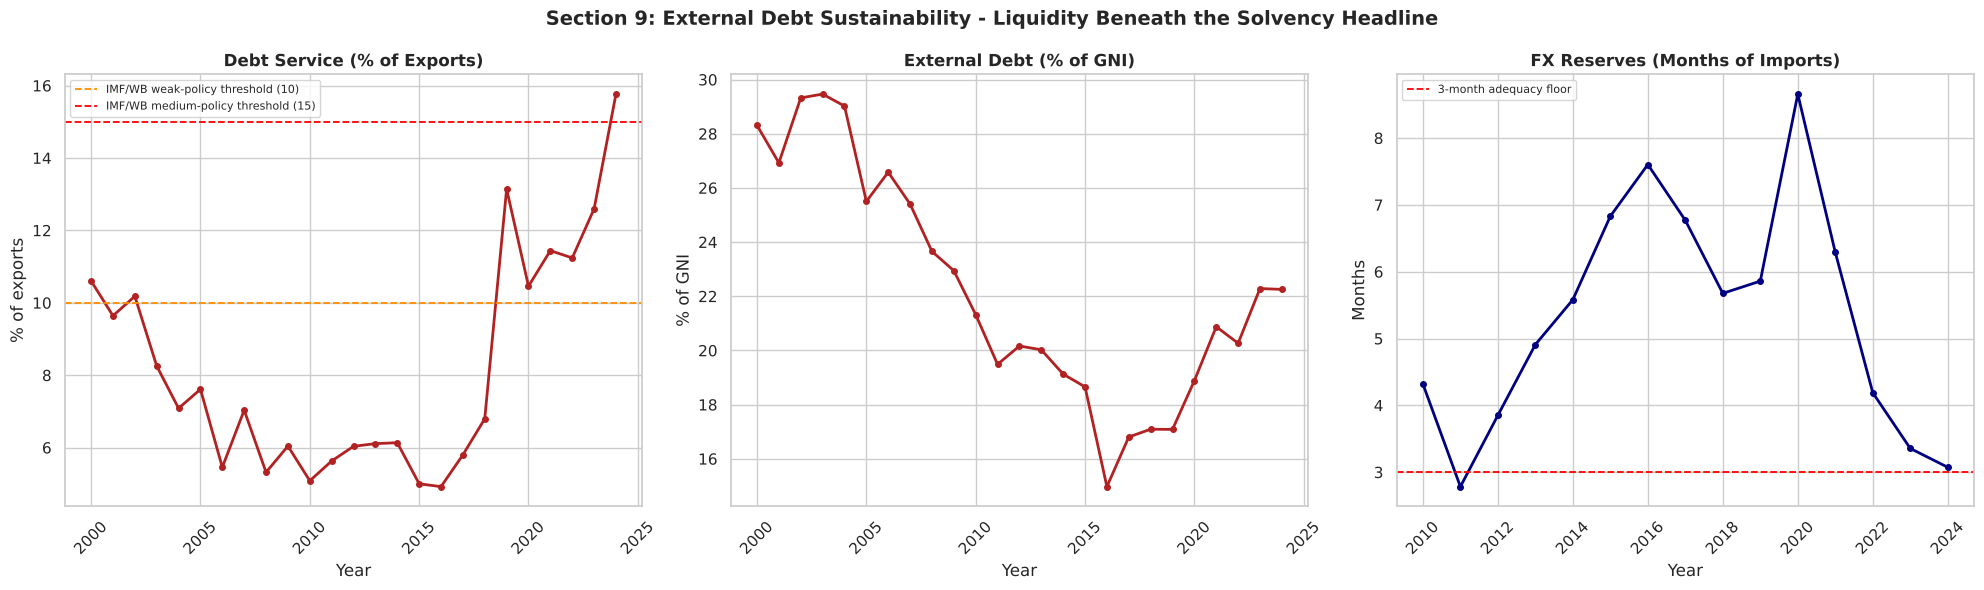

Debt service % exports: 2016=4.9  2024=15.8
Reserves (months): 2021=6.3  2024=3.1
Saved Section9_Debt_Sustainability.png


In [15]:
# Pull the liquidity-side debt metrics the headline debt/GDP ratio hides.
debt_service_x = get_wb_data("DT.TDS.DECT.EX.ZS", "BD")   # debt service, % exports
ext_debt_gni   = bd_extra.get("External Debt (% of GNI)")
reserves_mo    = get_wb_data("FI.RES.TOTL.MO", "BD")      # reserves, months of imports
current_acct   = get_wb_data("BN.CAB.XOKA.GD.ZS", "BD")   # current account, % GDP

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section 9: External Debt Sustainability - Liquidity Beneath the Solvency Headline",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
ax1.plot(debt_service_x["Year"], debt_service_x["Value"], marker="o", color="firebrick", linewidth=2, markersize=4)
ax1.axhline(10, color="darkorange", linestyle="--", linewidth=1.3, label="IMF/WB weak-policy threshold (10)")
ax1.axhline(15, color="red", linestyle="--", linewidth=1.3, label="IMF/WB medium-policy threshold (15)")
ax1.set_title("Debt Service (% of Exports)", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("% of exports"); ax1.legend(fontsize=8); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[1]
ax2.plot(ext_debt_gni["Year"], ext_debt_gni["Value"], marker="o", color="firebrick", linewidth=2, markersize=4)
ax2.set_title("External Debt (% of GNI)", fontweight="bold")
ax2.set_xlabel("Year"); ax2.set_ylabel("% of GNI"); ax2.tick_params(axis="x", rotation=45)

ax3 = axes[2]
rm = reserves_mo[reserves_mo["Year"] >= 2010]
ax3.plot(rm["Year"], rm["Value"], marker="o", color="navy", linewidth=2, markersize=4)
ax3.axhline(3, color="red", linestyle="--", linewidth=1.3, label="3-month adequacy floor")
ax3.set_title("FX Reserves (Months of Imports)", fontweight="bold")
ax3.set_xlabel("Year"); ax3.set_ylabel("Months"); ax3.legend(fontsize=8); ax3.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("Section9_Debt_Sustainability.png", dpi=150, bbox_inches="tight")
plt.show()

print("Debt service % exports: 2016={:.1f}  2024={:.1f}".format(
    float(debt_service_x[debt_service_x.Year==2016].Value.iloc[0]),
    float(debt_service_x[debt_service_x.Year==2024].Value.iloc[0])))
print("Reserves (months): 2021={:.1f}  2024={:.1f}".format(
    float(reserves_mo[reserves_mo.Year==2021].Value.iloc[0]),
    float(reserves_mo[reserves_mo.Year==2024].Value.iloc[0])))
print("Saved Section9_Debt_Sustainability.png")


## Section 10 — Remittance Shock Stress Test

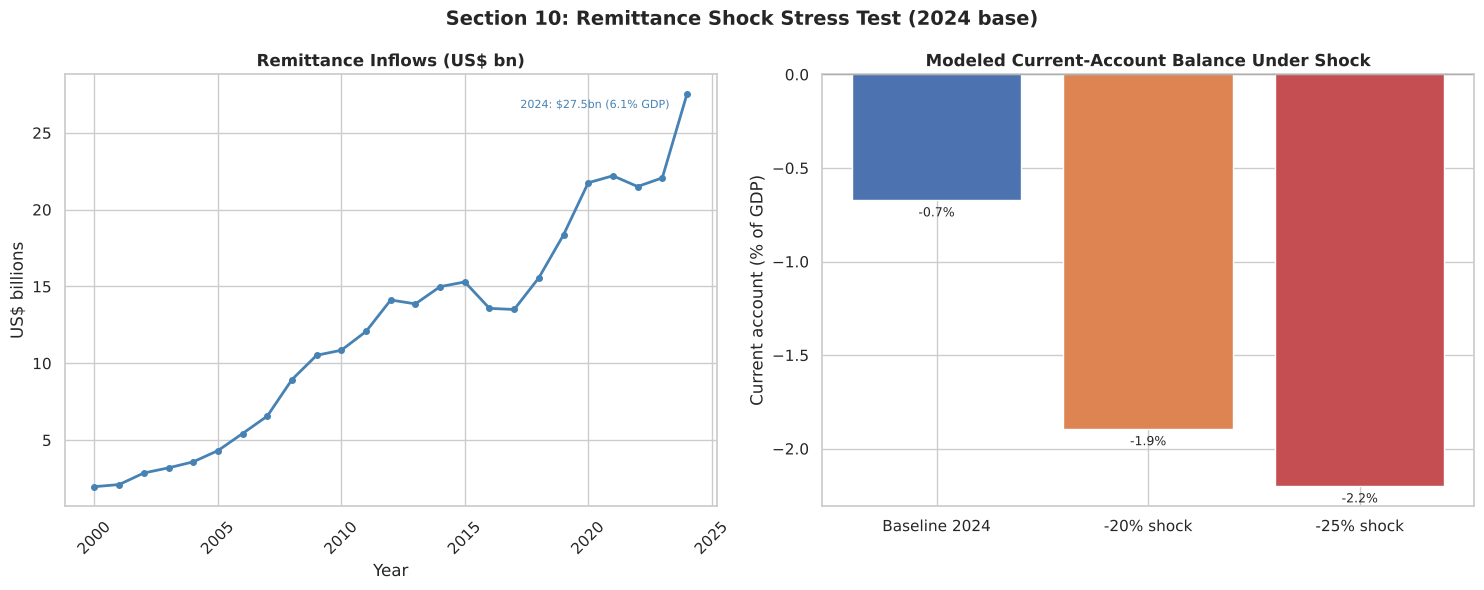

Baseline 2024: remittance loss = $0.0bn (0.00pp GDP) -> CA -0.67% GDP
-20% shock: remittance loss = $5.5bn (1.22pp GDP) -> CA -1.89% GDP
-25% shock: remittance loss = $6.9bn (1.53pp GDP) -> CA -2.20% GDP
Saved Section10_Remittance_StressTest.png


In [16]:
# Remittances and GDP in current US$ for a partial-equilibrium external-balance shock.
remit_usd = get_wb_data("BX.TRF.PWKR.CD.DT", "BD")
gdp_usd   = get_wb_data("NY.GDP.MKTP.CD", "BD")
ca_pct    = current_acct  # from Section 9

R  = float(remit_usd[remit_usd.Year==2024].Value.iloc[0])
Y  = float(gdp_usd[gdp_usd.Year==2024].Value.iloc[0])
CA = float(ca_pct[ca_pct.Year==2024].Value.iloc[0])

scenarios = {"Baseline 2024": 0.0, "-20% shock": 0.20, "-25% shock": 0.25}
ca_after = {}
for label, s in scenarios.items():
    ca_after[label] = CA - (R * s) / Y * 100   # remittance loss as share of GDP, off the current account

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Section 10: Remittance Shock Stress Test (2024 base)", fontsize=14, fontweight="bold")

ax1 = axes[0]
ax1.plot(remit_usd["Year"], remit_usd["Value"]/1e9, marker="o", color="steelblue", linewidth=2, markersize=4)
ax1.set_title("Remittance Inflows (US$ bn)", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("US$ billions"); ax1.tick_params(axis="x", rotation=45)
ax1.annotate(f"2024: ${R/1e9:.1f}bn ({R/Y*100:.1f}% GDP)", xy=(2024, R/1e9),
             xytext=(-120, -10), textcoords="offset points", fontsize=8, color="steelblue")

ax2 = axes[1]
labels = list(ca_after.keys()); vals = list(ca_after.values())
bars = ax2.bar(labels, vals, color=["#4c72b0", "#dd8452", "#c44e52"])
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Modeled Current-Account Balance Under Shock", fontweight="bold")
ax2.set_ylabel("Current account (% of GDP)")
for b, v in zip(bars, vals):
    ax2.annotate(f"{v:.1f}%", xy=(b.get_x()+b.get_width()/2, v), xytext=(0, 6 if v>=0 else -12),
                 textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("Section10_Remittance_StressTest.png", dpi=150, bbox_inches="tight")
plt.show()

for label, s in scenarios.items():
    print(f"{label}: remittance loss = ${R*s/1e9:.1f}bn ({R*s/Y*100:.2f}pp GDP) -> CA {ca_after[label]:.2f}% GDP")
print("Saved Section10_Remittance_StressTest.png")


## Section 11 — Vietnam FDI Counterfactual

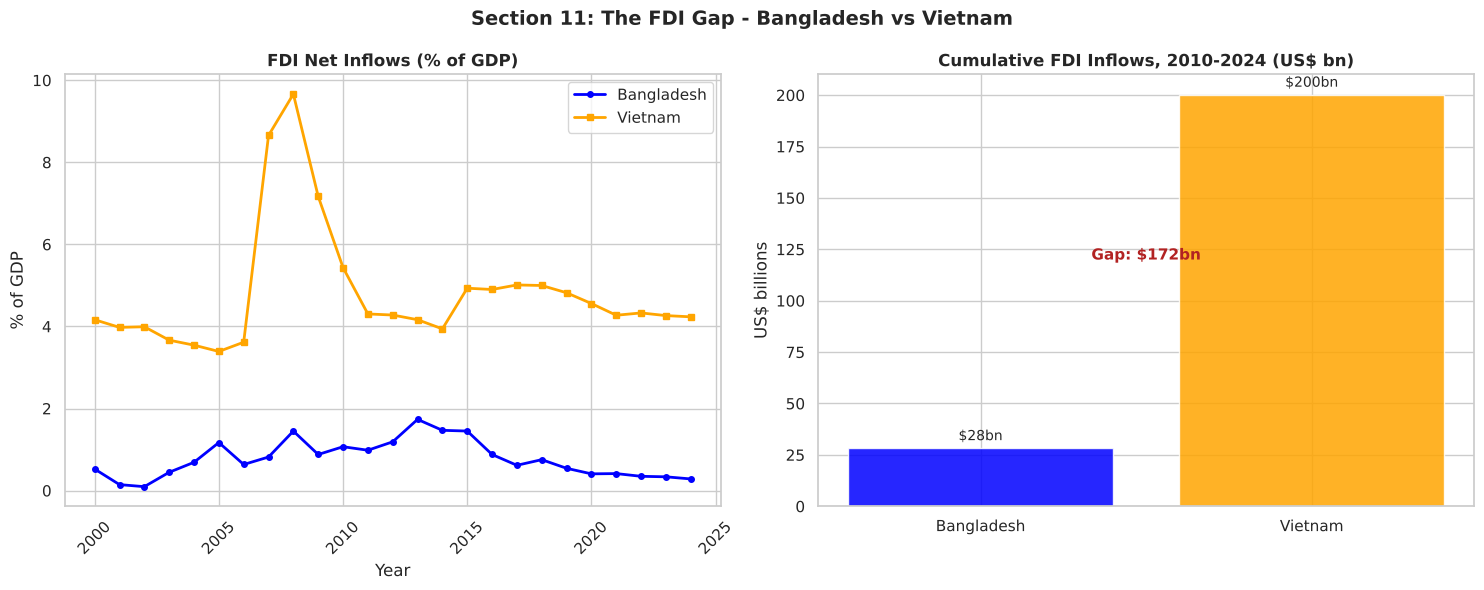

Cumulative FDI 2010-2024: BD=$28bn  VN=$200bn  gap=$172bn
Saved Section11_Vietnam_FDI_Counterfactual.png


In [17]:
fdi_pct_bd = bd_core.get("FDI (% of GDP)")
fdi_pct_vn = get_wb_data("BX.KLT.DINV.WD.GD.ZS", "VN")
fdi_usd_bd = get_wb_data("BX.KLT.DINV.CD.WD", "BD")
fdi_usd_vn = get_wb_data("BX.KLT.DINV.CD.WD", "VN")

cum_bd = fdi_usd_bd[(fdi_usd_bd.Year>=2010)&(fdi_usd_bd.Year<=2024)].Value.sum()
cum_vn = fdi_usd_vn[(fdi_usd_vn.Year>=2010)&(fdi_usd_vn.Year<=2024)].Value.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Section 11: The FDI Gap - Bangladesh vs Vietnam", fontsize=14, fontweight="bold")

ax1 = axes[0]
ax1.plot(fdi_pct_bd["Year"], fdi_pct_bd["Value"], marker="o", color="blue", linewidth=2, markersize=4, label="Bangladesh")
ax1.plot(fdi_pct_vn["Year"], fdi_pct_vn["Value"], marker="s", color="orange", linewidth=2, markersize=4, label="Vietnam")
ax1.set_title("FDI Net Inflows (% of GDP)", fontweight="bold")
ax1.set_xlabel("Year"); ax1.set_ylabel("% of GDP"); ax1.legend(); ax1.tick_params(axis="x", rotation=45)

ax2 = axes[1]
bars = ax2.bar(["Bangladesh", "Vietnam"], [cum_bd/1e9, cum_vn/1e9], color=["blue", "orange"], alpha=0.85)
ax2.set_title("Cumulative FDI Inflows, 2010-2024 (US$ bn)", fontweight="bold")
ax2.set_ylabel("US$ billions")
for b, v in zip(bars, [cum_bd/1e9, cum_vn/1e9]):
    ax2.annotate(f"${v:.0f}bn", xy=(b.get_x()+b.get_width()/2, v), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=10)
ax2.annotate(f"Gap: ${(cum_vn-cum_bd)/1e9:.0f}bn", xy=(0.5, max(cum_bd, cum_vn)/1e9*0.6),
             ha="center", fontsize=11, fontweight="bold", color="firebrick")

plt.tight_layout()
plt.savefig("Section11_Vietnam_FDI_Counterfactual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cumulative FDI 2010-2024: BD=${cum_bd/1e9:.0f}bn  VN=${cum_vn/1e9:.0f}bn  gap=${(cum_vn-cum_bd)/1e9:.0f}bn")
print("Saved Section11_Vietnam_FDI_Counterfactual.png")


## Section 12 — Exchange-Rate Pass-Through & Demand-Side Growth Decomposition

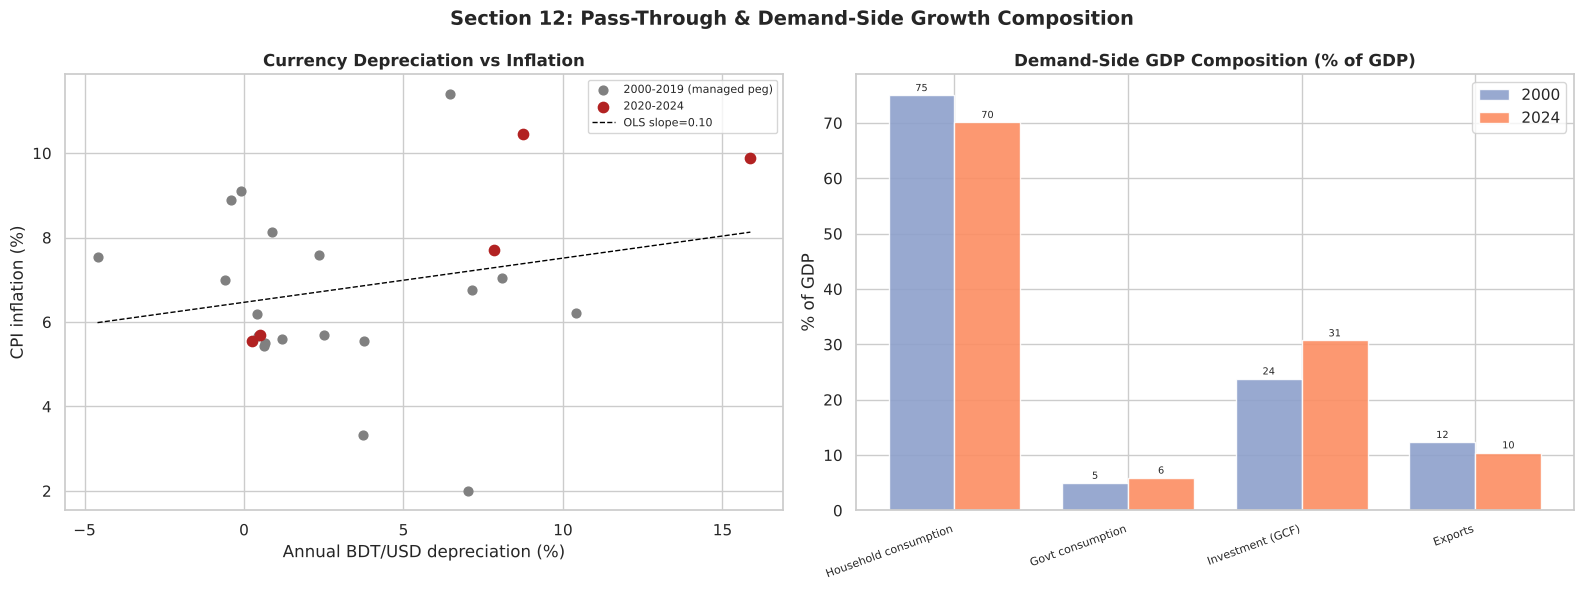

Pass-through OLS (2001-2024, n=24): inflation = 6.47 + 0.105 x depreciation%
R^2 = 0.05, slope SE = 0.097, t = 1.08 (weak, not statistically significant)
Demand shares 2000 -> 2024:
  Household consumption: 75.0% -> 70.1%
  Govt consumption: 5.0% -> 5.9%
  Investment (GCF): 23.8% -> 30.7%
  Exports: 12.3% -> 10.5%
Saved Section12_PassThrough_Decomposition.png


In [18]:
inflation = bd_core.get("Inflation (%)")
exch = bd_extra.get("Exchange Rate (BDT per USD)").copy()
exch["depr"] = exch["Value"].pct_change() * 100
m = pd.merge(exch[["Year", "depr"]], inflation, on="Year").dropna()
m = m[m["Year"] >= 2000]
slope, intercept = np.polyfit(m["depr"], m["Value"], 1)

# Demand-side GDP shares
shares = {
    "Household consumption": get_wb_data("NE.CON.PRVT.ZS", "BD"),
    "Govt consumption":      get_wb_data("NE.CON.GOVT.ZS", "BD"),
    "Investment (GCF)":      get_wb_data("NE.GDI.TOTL.ZS", "BD"),
    "Exports":               get_wb_data("NE.EXP.GNFS.ZS", "BD"),
}
def share_val(df, yr):
    s = df[df.Year == yr]; return float(s.Value.iloc[0]) if len(s) else np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Section 12: Pass-Through & Demand-Side Growth Composition", fontsize=14, fontweight="bold")

ax1 = axes[0]
pre = m[m["Year"] <= 2019]; post = m[m["Year"] >= 2020]
ax1.scatter(pre["depr"], pre["Value"], color="gray", label="2000-2019 (managed peg)", s=40)
ax1.scatter(post["depr"], post["Value"], color="firebrick", label="2020-2024", s=55)
xs = np.linspace(m["depr"].min(), m["depr"].max(), 50)
ax1.plot(xs, intercept + slope*xs, color="black", linestyle="--", linewidth=1, label=f"OLS slope={slope:.2f}")
ax1.set_title("Currency Depreciation vs Inflation", fontweight="bold")
ax1.set_xlabel("Annual BDT/USD depreciation (%)"); ax1.set_ylabel("CPI inflation (%)"); ax1.legend(fontsize=8)

ax2 = axes[1]
cats = list(shares.keys())
v2000 = [share_val(shares[c], 2000) for c in cats]
v2024 = [share_val(shares[c], 2024) for c in cats]
x = np.arange(len(cats)); w = 0.38
ax2.bar(x - w/2, v2000, w, label="2000", color="#8da0cb", alpha=0.9)
ax2.bar(x + w/2, v2024, w, label="2024", color="#fc8d62", alpha=0.9)
ax2.set_title("Demand-Side GDP Composition (% of GDP)", fontweight="bold")
ax2.set_ylabel("% of GDP"); ax2.set_xticks(x); ax2.set_xticklabels(cats, rotation=20, ha="right", fontsize=8); ax2.legend()
for i, (a, b) in enumerate(zip(v2000, v2024)):
    ax2.annotate(f"{a:.0f}", xy=(i - w/2, a), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=7)
    ax2.annotate(f"{b:.0f}", xy=(i + w/2, b), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("Section12_PassThrough_Decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
_fit = intercept + slope*m["depr"]
_r2 = 1 - ((m["Value"]-_fit)**2).sum() / ((m["Value"]-m["Value"].mean())**2).sum()
_se = np.sqrt(((m["Value"]-_fit)**2).sum()/(len(m)-2) / ((m["depr"]-m["depr"].mean())**2).sum())
print(f"Pass-through OLS ({int(m['Year'].min())}-{int(m['Year'].max())}, n={len(m)}): inflation = {intercept:.2f} + {slope:.3f} x depreciation%")
print(f"R^2 = {_r2:.2f}, slope SE = {_se:.3f}, t = {slope/_se:.2f} (weak, not statistically significant)")
print("Demand shares 2000 -> 2024:")
for c in cats:
    print(f"  {c}: {share_val(shares[c],2000):.1f}% -> {share_val(shares[c],2024):.1f}%")
print("Saved Section12_PassThrough_Decomposition.png")


## Section 13 — Liquidity Extensions: Reserves in US$, Short-Term Debt, Shock vs. Reserves

In [19]:
# Section 13: Liquidity extensions (reserves in US$, short-term debt, shock vs. reserves)
import time, requests, pandas as pd

def wb(indicator, country="BD", start=2000, end=2024, tries=6):
    """Reliable World Bank fetch: https, date-limited, long timeout, retries, prints the reason if it fails."""
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}"
    params = {"format": "json", "per_page": 400, "date": f"{start}:{end}"}
    err = None
    for attempt in range(tries):
        try:
            r = requests.get(url, params=params, timeout=90)
            r.raise_for_status()
            p = r.json()
            if len(p) > 1 and p[1]:
                df = pd.DataFrame(p[1])[["date", "value"]].dropna()
                df.columns = ["Year", "Value"]; df["Year"] = df["Year"].astype(int)
                return df.sort_values("Year").reset_index(drop=True)
            err = "empty response"
        except Exception as e:
            err = repr(e)
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Could not download {indicator}: {err}")

res_usd    = wb("FI.RES.TOTL.CD")      # total reserves, current US$
st_debt    = wb("DT.DOD.DSTC.IR.ZS")   # short-term external debt, % of total reserves
debt_usd   = wb("DT.DOD.DECT.CD")      # external debt stock, current US$
fx         = wb("PA.NUS.FCRF")         # official exchange rate, BDT per USD (annual average)
remit_usd2 = wb("BX.TRF.PWKR.CD.DT")   # remittances, current US$ (same series as Section 10)

v = lambda df, y: float(df[df.Year == y].Value.iloc[0])
Res, R24 = v(res_usd, 2024), v(remit_usd2, 2024)

for s in (0.20, 0.25):
    print(f"{int(s*100)}% shock = ${R24*s/1e9:.2f}bn = {R24*s/Res*100:.1f}% of 2024 reserves (${Res/1e9:.2f}bn)")
print("Reserves $bn 2021 -> 2024:", round(v(res_usd, 2021)/1e9, 1), "->", round(Res/1e9, 1))
print("Short-term debt % reserves 2021 -> 2024:", round(v(st_debt, 2021), 1), "->", round(v(st_debt, 2024), 1))
print("External debt $bn 2016 -> 2024:", round(v(debt_usd, 2016)/1e9, 1), "->", round(v(debt_usd, 2024)/1e9, 1))
print("BDT/USD 2021 -> 2024:", round(v(fx, 2021), 1), "->", round(v(fx, 2024), 1))

print(f"20% shock vs 2021 reserves: {R24*0.20/v(res_usd, 2021)*100:.1f}%")
print(f"Import cover after 20% shock: {3.1*(1 - R24*0.20/Res):.1f} months")

20% shock = $5.50bn = 25.7% of 2024 reserves ($21.39bn)
25% shock = $6.88bn = 32.2% of 2024 reserves ($21.39bn)
Reserves $bn 2021 -> 2024: 46.2 -> 21.4
Short-term debt % reserves 2021 -> 2024: 39.2 -> 60.5
External debt $bn 2016 -> 2024: 41.6 -> 104.5
BDT/USD 2021 -> 2024: 85.1 -> 115.6
20% shock vs 2021 reserves: 11.9%
Import cover after 20% shock: 2.3 months


In [20]:
# Supporting figures cited in the writing sample (reuses wb() and v from the cell above)
fdi_pct = wb("BX.KLT.DINV.WD.GD.ZS")   # FDI net inflows, % of GDP
ca_pct  = wb("BN.CAB.XOKA.GD.ZS")      # current account, % of GDP
ds      = wb("DT.TDS.DECT.EX.ZS")      # debt service, % of exports
gni     = wb("DT.DOD.DECT.GN.ZS")      # external debt, % of GNI

print("FDI % of GDP 2013 -> 2024:", round(v(fdi_pct, 2013), 2), "->", round(v(fdi_pct, 2024), 2))
print("Current account % GDP 2021, 2022, 2024:", round(v(ca_pct, 2021), 2), round(v(ca_pct, 2022), 2), round(v(ca_pct, 2024), 2))
r23, r24 = v(remit_usd2, 2023), v(remit_usd2, 2024)
print(f"Remittances $bn 2023 -> 2024: {r23/1e9:.2f} -> {r24/1e9:.2f} ({(r24/r23-1)*100:.1f}% growth)")
print(f"2024 remittances after a 20% fall: ${r24*0.8/1e9:.2f}bn (vs 2023: ${r23/1e9:.2f}bn)")
print("Debt service % exports 2016-2024:", {y: round(v(ds, y), 1) for y in range(2016, 2025)})
print("External debt % GNI 2016, 2024:", round(v(gni, 2016), 1), round(v(gni, 2024), 1))

FDI % of GDP 2013 -> 2024: 1.74 -> 0.28
Current account % GDP 2021, 2022, 2024: -3.79 -3.81 -0.67
Remittances $bn 2023 -> 2024: 22.07 -> 27.52 (24.7% growth)
2024 remittances after a 20% fall: $22.02bn (vs 2023: $22.07bn)
Debt service % exports 2016-2024: {2016: 4.9, 2017: 5.8, 2018: 6.8, 2019: 13.1, 2020: 10.5, 2021: 11.4, 2022: 11.2, 2023: 12.6, 2024: 15.8}
External debt % GNI 2016, 2024: 15.0 22.3
